In [1]:
# Q 4.1

x, y = [1, 2, 3, 10], [10, 20, 30, 40]
z = zip(x, y)
print(list(z))
            
def join(x,y):
    return x, y

z = map(join,x,y)
print(list(z))

[(1, 10), (2, 20), (3, 30), (10, 40)]
[(1, 10), (2, 20), (3, 30), (10, 40)]


In [2]:
# Q 4.3
import numpy as np

user = input('Choose rock, paper or scissors (R, P, S):')
# Assign number to input
if user == 'R':
    user = 1
elif user == 'P':
    user = 2
elif user == 'S':
    user = 3
else:
    print('Please input R, P or S >:O')

bot = np.random.randint(1,3+1)

if user == bot:
    # Same choice is a tie
    print("It's a tie!")
elif (user == 1 and bot == 3) or (user == 3 and bot == 2) or (user == 2 and bot == 1):
    # Rock beats Scissor / Scissors beats Paper / Paper beats Rock
    print('You win!')
else:
    print('You lose :(')

Choose rock, paper or scissors (R, P, S): R


You win!


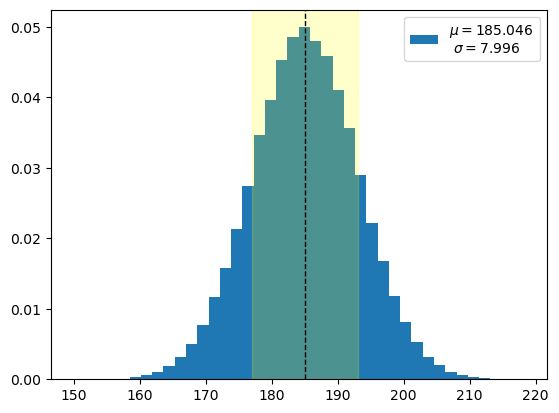

The probability that someone is 185 cm tall or less is 50.23 %
The probability that someone is within 8.00 of 185 cm is 68.27 %


In [3]:
# Q 4.4
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

h = np.random.normal(loc=185,scale=8,size=100000)

avg = np.mean(h)
std = np.std(h)

plt.hist(h, bins=40, label=f'$\mu=${avg:.3f} \n $\sigma=${std:.3f}', density=True)
plt.axvline(avg, color='k', linestyle='dashed', linewidth=1)
plt.axvspan(avg-std, avg+std, alpha=.2, color='yellow')
plt.legend()
plt.show()

cdf = norm.cdf(185, scale=std, loc=avg)
P = ( 1 - cdf ) * 100
print(f"The probability that someone is 185 cm tall or less is {P:.2f} %")

Plow = norm.cdf(avg-std, scale=std, loc=avg)
Phigh = norm.cdf(avg+std, scale=std, loc=avg)
Ptot = ( Phigh - Plow) * 100
print(f"The probability that someone is within {std:.2f} of 185 cm is {Ptot:.2f} %")

In [118]:
# Q 4.6
import numpy as np

def integrate(f,a,b):
    n = 10000000
    x = np.random.uniform(a,b,n)
    y = eval(f)
    integral = ( ( b - a ) / n ) * sum (y)
    return integral

f = input('f(x) =')
a = float(input('Lower boundary, a ='))
b = float(input('Upper boundary, b ='))

print(integrate(f,a,b))

2.0000569162047332


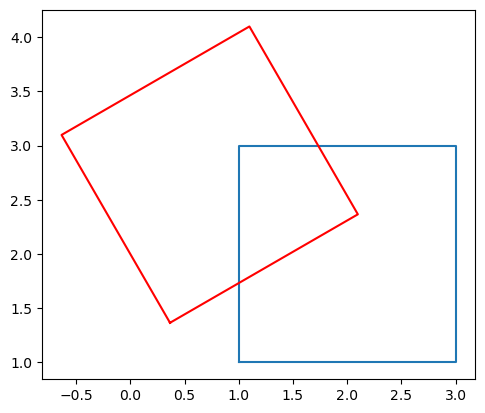

In [5]:
# Q 4.12
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])

angle = 30
theta = np.radians(angle)
rotor = np.cos(theta) + 1j * np.sin(theta)
xy = rotor * (x+y*1j)

plt.plot(x,y)
plt.plot(xy.real,xy.imag, color='red')
plt.gca().set_aspect(1)
plt.show()

In [6]:
# Q 4.14 
import numpy as np

def funcfilter(func, seq):
    seq = np.asarray([seq])
    print(seq)
    s = seq > 0
    n = seq[s]
    filt = func(n)
    return filt

sq = np.array([-100, -10, 0, 10, 100])
result = funcfilter(np.log10, sq)
print("Result log10:", result)

sq = 100
result = funcfilter(np.log10, sq)
print("Result log10:", result)

[[-100  -10    0   10  100]]
Result log10: [1. 2.]
[100]
Result log10: [2.]


In [7]:
# Q 4.16 
from astropy.cosmology import Planck18
from scipy import integrate
from math import sqrt

H0 = Planck18.H0.value
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0

def t(z):
    y = 1 / ( ( 1 + z ) * ( H0 * sqrt( Om0 * ( 1 + z )**3 + Ode0 ) ) )     # units of s.Mpc/km
    return y

t2 = integrate.quad(t, 0, 2)
# convert to sec by multiplying by 5,3855e17 (km in a Mpc) and to years by dividing by 3600*24*365
t = t2[0] * 3.0856e19 / (3600*24*365) * 1e-9
print(f'{t:f} ± {(t2[1]*1e-9):.0e} Gyr')

10.533148 ± 2e-24 Gyr


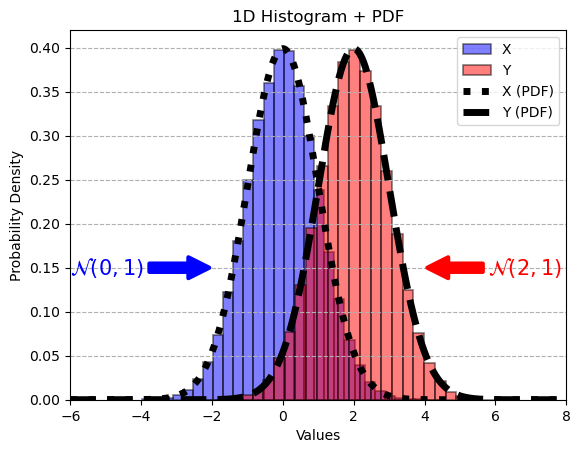

In [1]:
# Q 4.21 (pending)
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

X = np.random.normal(0,1,100000)
Y = np.random.normal(2,1,100000)

x = np.linspace(-6,8,1000)


plt.hist(X,
         bins=30,
         density=True,
         color='blue',
         alpha=0.5,
         edgecolor='black',
         linewidth=1.2,
         label='X')
plt.hist(Y,
         bins=30,
         density=True,
         color='red',
         alpha=0.5,
         edgecolor='black',
         linewidth=1.2,
         label='Y')

plt.plot(x, norm.pdf(x,0,1),
         label='X (PDF)',
         color='black',
         linewidth=5,
         linestyle='dotted',)
plt.plot(x, norm.pdf(x,2,1),
         label='Y (PDF)',
         color='black',
         linewidth=5,
         linestyle='--')

y_arrow = 0.15
plt.annotate(r'$\mathcal{N}(0,1)$',
            xy=(-2, y_arrow),
            xytext=(-6, y_arrow),
            fontsize=15,
            color='blue',
            va='center',
            arrowprops=dict(
                arrowstyle='simple',
                lw=3,
                color='blue',
                mutation_scale=30))
plt.annotate(r'$\mathcal{N}(2,1)$',
            xy=(4, y_arrow),
            xytext=(5.8, y_arrow),
            fontsize=15,
            color='red',
            va='center',
            arrowprops=dict(
                arrowstyle='simple',
                lw=3,
                color='red',
                mutation_scale=30))

plt.title('1D Histogram + PDF')
plt.xlabel('Values')
plt.ylabel('Probability Density')

plt.xlim(-6,8)
plt.ylim(0,.42)

plt.grid(axis='y',
         linestyle='--')
plt.legend()
plt.show()

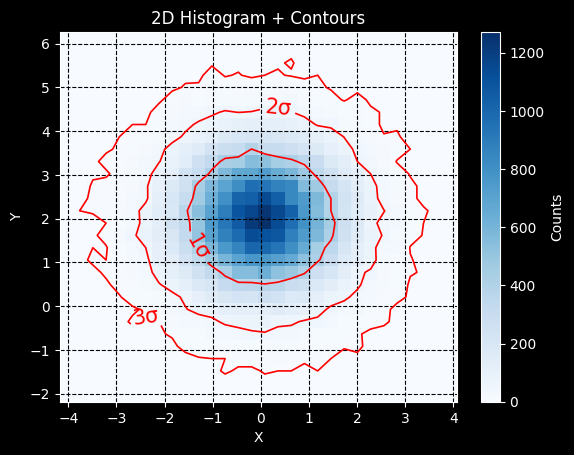

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data
X = np.random.normal(0, 1, 100000)
Y = np.random.normal(2, 1, 100000)

# Compute 2D histogram (empirical density)
bins = 30
H, xedges, yedges = np.histogram2d(X, Y, bins=bins)

# Total number of samples
total = H.sum()

# Sort bins by density (highest first)
H_flat = H.ravel()
H_sorted = np.sort(H_flat)[::-1]

# Cumulative probability
cumulative = np.cumsum(H_sorted)
cumulative /= cumulative[-1]

# HDR threshold
def get_level(p):
    return H_sorted[np.searchsorted(cumulative, p)]

# 1σ, 2σ, 3σ probability levels (2D Gaussian equivalents)
levels = [
    get_level(0.6827),
    get_level(0.9545),
    get_level(0.9973)
]

# Create bin-center grid for contouring
X_centers = 0.5 * (xedges[:-1] + xedges[1:])
Y_centers = 0.5 * (yedges[:-1] + yedges[1:])
X_grid, Y_grid = np.meshgrid(X_centers, Y_centers)

# Plot histogram
plt.figure()
im = plt.hist2d(X, Y, bins=bins, cmap='Blues')
plt.colorbar(label="Counts")

# Draw contours
contours = plt.contour(
    X_grid,
    Y_grid,
    H.T,
    levels=sorted(levels),
    colors=['red']*3,
    linewidths=1.2
)

fmt = {
    levels[0]: '1σ',
    levels[1]: '2σ',
    levels[2]: '3σ'
}
plt.clabel(contours, inline=True, fontsize=15, fmt=fmt)

plt.grid(linestyle='--', color='k')
plt.title("2D Histogram + Contours")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()